In [1]:
import pandas as pd

# CSV-Datei aus dem data-Unterordner einlesen
df = pd.read_csv('../data/movies2019.csv')

# Erste fünf Zeilen anzeigen
print("Erste 5 Zeilen des Datensatzes:")
print(df.head())

Erste 5 Zeilen des Datensatzes:
   Rank                      Movie  Release Date    Distributor      Genre  \
0     1          Avengers: Endgame  Apr 26, 2019    Walt Disney     Action   
1     2             Captain Marvel   Mar 8, 2019    Walt Disney     Action   
2     3                Toy Story 4  Jun 21, 2019    Walt Disney  Adventure   
3     4              The Lion King  Jul 19, 2019    Walt Disney  Adventure   
4     5  Spider-Man: Far From Home   Jul 2, 2019  Sony Pictures     Action   

     2019 Gross Tickets Sold  
0  $857,190,335   94,093,340  
1  $426,829,839   46,852,891  
2  $404,979,743   44,454,417  
3  $403,748,078   44,319,218  
4  $354,788,925   38,944,997  


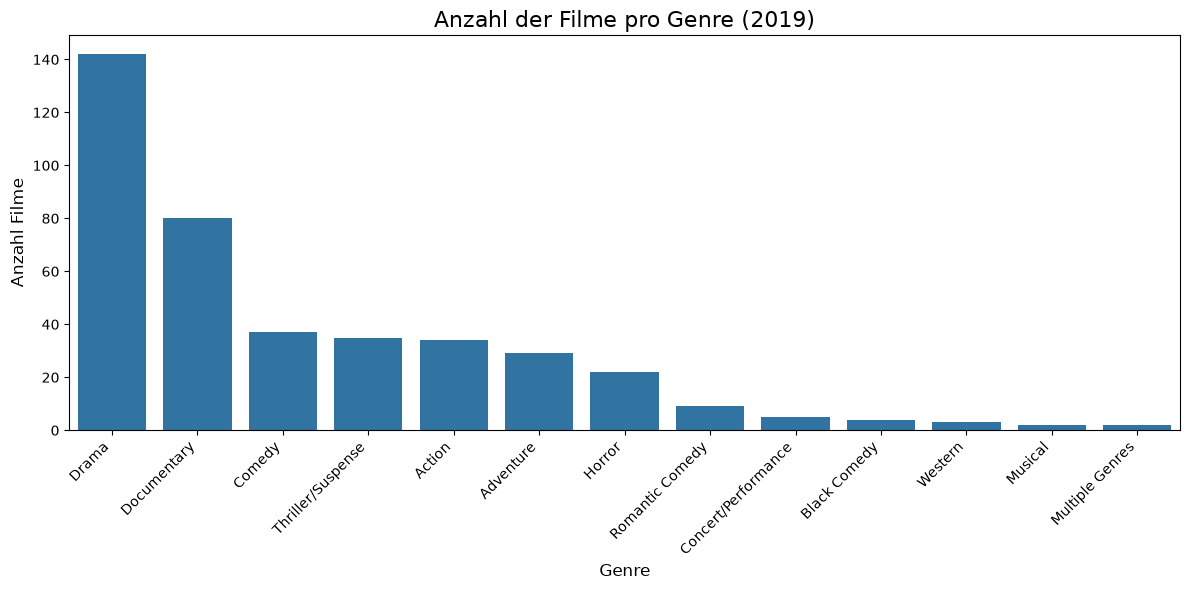

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot-Größe anpassen
plt.figure(figsize=(12, 6))

# Count Plot erstellen (absteigend sortiert)
sns.countplot(
    data=df, 
    x='Genre', 
    order=df['Genre'].value_counts().index
)

# Titel und Achsenbeschriftungen
plt.title('Anzahl der Filme pro Genre (2019)', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Anzahl Filme', fontsize=12)

# X-Achsen-Labels rotieren
plt.xticks(rotation=45, ha='right')

# Layout optimieren
plt.tight_layout()
plt.show()

In [3]:
def convert_gross(value):
    """
    Konvertiert Strings wie '$857,190,335' in Zahlen (Float).
    """
    if isinstance(value, str):
        # $, M und Kommas entfernen
        value = value.replace('$', '').replace('M', '').replace(',', '')
        # Zu float konvertieren
        return float(value)
    return value

# Auf die Spalte anwenden
df['2019 Gross'] = df['2019 Gross'].apply(convert_gross)

# Gesamtumsatz berechnen
total_gross = df['2019 Gross'].sum()
print(f"Gesamtumsatz 2019: ${total_gross:,.2f} Millionen")

Gesamtumsatz 2019: $6,786,167,073.00 Millionen


In [4]:
# Gruppierung nach Genre mit count und sum
genre_stats = df.groupby('Genre')['2019 Gross'].agg(['count', 'sum'])

# Sortierung nach Anzahl Filme (absteigend)
genre_stats = genre_stats.sort_values('count', ascending=False)

# Spalten umbenennen
genre_stats.columns = ['Anzahl Filme', 'Gesamtumsatz (Mio)']

# Formatierung des Umsatzes (als String mit $-Zeichen)
genre_stats['Gesamtumsatz (Mio)'] = genre_stats['Gesamtumsatz (Mio)'].map('${:,.2f}M'.format)

print("Summenstatistik nach Genre:")
print(genre_stats)

# Genre mit den meisten und wenigsten Filmen
most_genre = genre_stats.index[0]
least_genre = genre_stats.index[-1]

print(f"\nDie meisten Filme: {most_genre} ({genre_stats.loc[most_genre, 'Anzahl Filme']} Filme)")
print(f"Die wenigsten Filme: {least_genre} ({genre_stats.loc[least_genre, 'Anzahl Filme']} Filme)")

Summenstatistik nach Genre:
                     Anzahl Filme  Gesamtumsatz (Mio)
Genre                                                
Drama                         142    $541,483,413.00M
Documentary                    80     $60,283,496.00M
Comedy                         37    $518,142,283.00M
Thriller/Suspense              35    $542,834,290.00M
Action                         34  $2,436,683,565.00M
Adventure                      29  $2,151,730,471.00M
Horror                         22    $375,969,919.00M
Romantic Comedy                 9     $81,761,874.00M
Concert/Performance             5      $1,758,562.00M
Black Comedy                    4     $36,609,765.00M
Western                         3      $1,707,418.00M
Multiple Genres                 2      $3,545,060.00M
Musical                         2     $33,582,542.00M

Die meisten Filme: Drama (142 Filme)
Die wenigsten Filme: Musical (2 Filme)


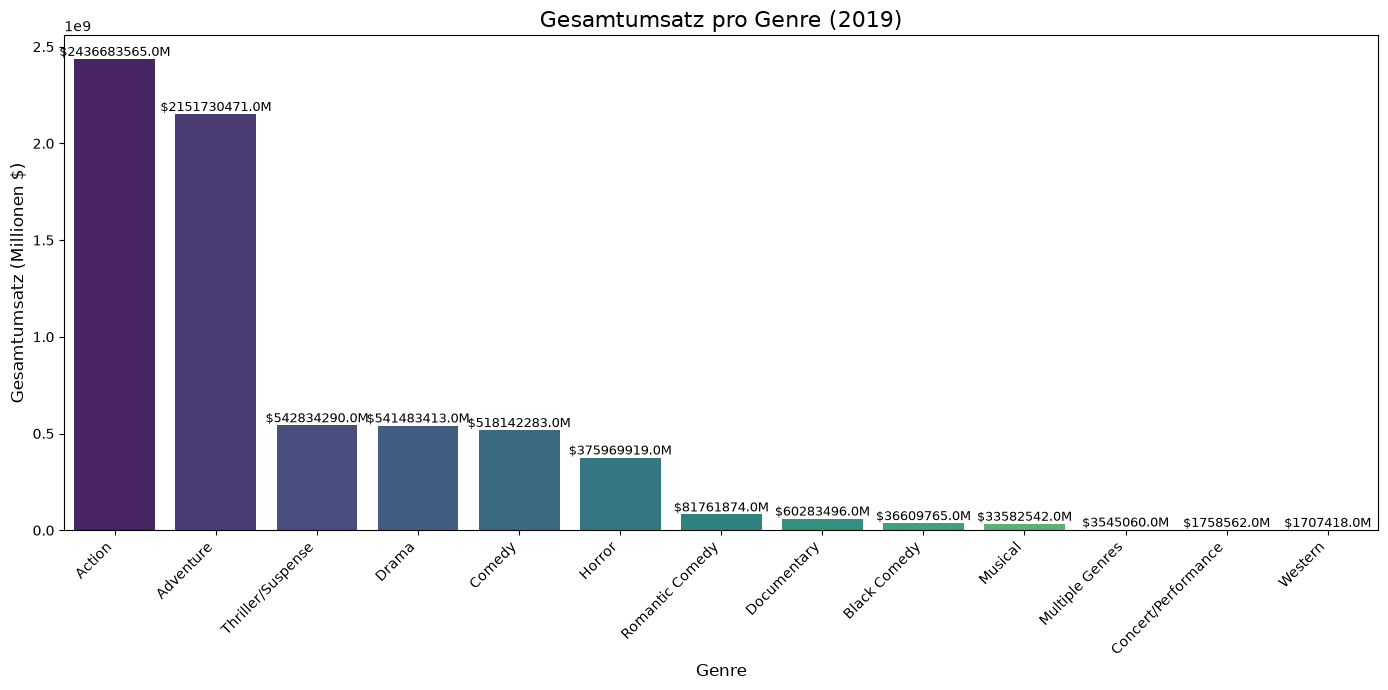

In [6]:
# Gruppierung für den Plot
genre_sum = df.groupby('Genre')['2019 Gross'].sum().sort_values(ascending=False)

# Plot erstellen
plt.figure(figsize=(14, 7))
sns.barplot(
    x=genre_sum.index, 
    y=genre_sum.values, 
    hue=genre_sum.index,      # Neu: hue auf x gesetzt
    palette='viridis',
    legend=False              # Neu: Legende deaktivieren
)

# Titel und Achsen
plt.title('Gesamtumsatz pro Genre (2019)', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Gesamtumsatz (Millionen $)', fontsize=12)

# X-Achsen-Labels rotieren
plt.xticks(rotation=45, ha='right')

# Werte über den Balken anzeigen
for i, v in enumerate(genre_sum.values):
    plt.text(i, v + 5, f'${v:.1f}M', ha='center', va='bottom', fontsize=9)

# Layout optimieren
plt.tight_layout()
plt.show()

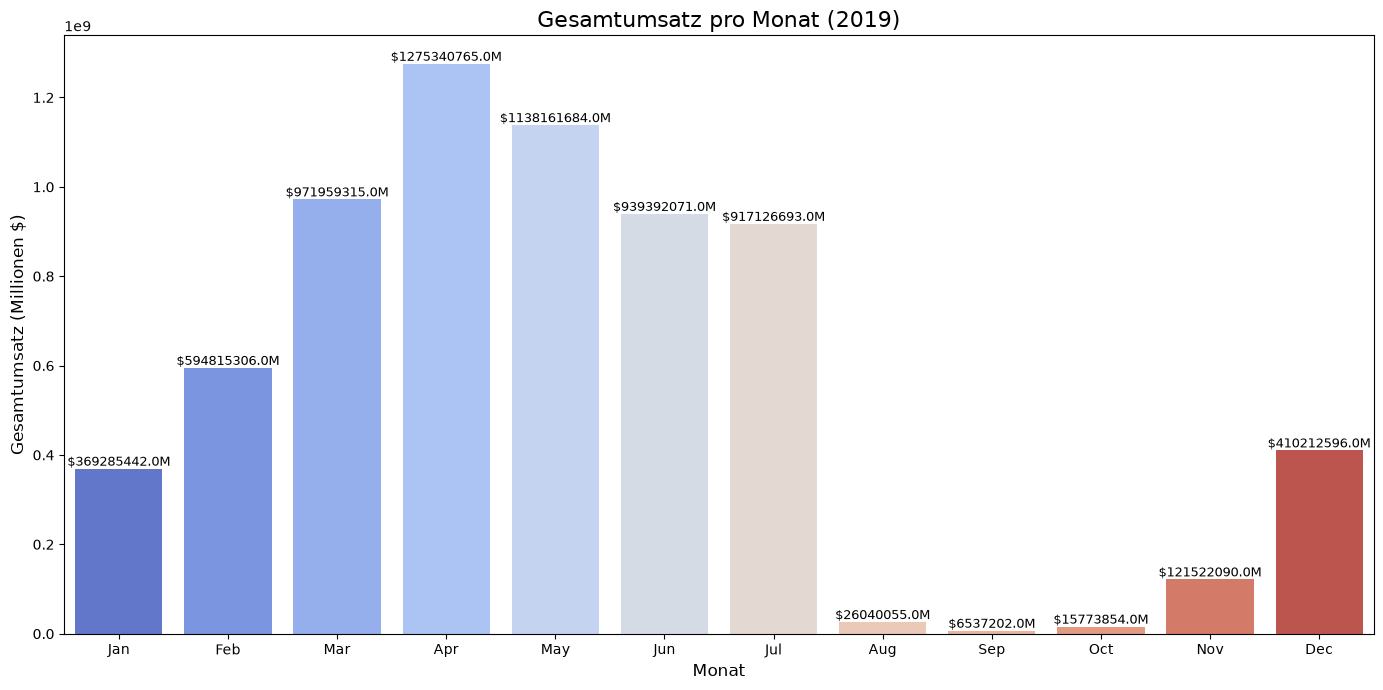

In [7]:
# Release Date in Datetime konvertieren
df['Release Date'] = pd.to_datetime(df['Release Date'])

# Monat extrahieren
df['Month'] = df['Release Date'].dt.month

# Monatsnamen für bessere Lesbarkeit
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month Name'] = df['Month'].map(lambda x: month_names[x-1])

# Umsatz nach Monat aggregieren
monthly_gross = df.groupby('Month')['2019 Gross'].sum().sort_index()

# Plot erstellen
plt.figure(figsize=(14, 7))
sns.barplot(
    x=month_names, 
    y=monthly_gross.values, 
    hue=month_names,
    palette='coolwarm',
    legend=False
)

# Titel und Achsen
plt.title('Gesamtumsatz pro Monat (2019)', fontsize=16)
plt.xlabel('Monat', fontsize=12)
plt.ylabel('Gesamtumsatz (Millionen $)', fontsize=12)

# Werte über den Balken anzeigen
for i, v in enumerate(monthly_gross.values):
    plt.text(i, v + 5, f'${v:.1f}M', ha='center', va='bottom', fontsize=9)

# Layout optimieren
plt.tight_layout()
plt.show()

In [8]:
# Gruppierung und Sortierung
distributor_gross = df.groupby('Distributor')['2019 Gross'].sum().sort_values(ascending=False)

# Top 5 anzeigen
top5 = distributor_gross.head(5)

print("Top 5 Distributoren nach Gesamtumsatz 2019:")
print(top5)
print()

# Formatierte Ausgabe
print("Detaillierte Ausgabe:")
for i, (distributor, gross) in enumerate(top5.items(), 1):
    print(f"{i}. {distributor}: ${gross:,.2f}M")

Top 5 Distributoren nach Gesamtumsatz 2019:
Distributor
Walt Disney      2.611281e+09
Warner Bros.     9.055731e+08
Universal        8.802197e+08
Sony Pictures    7.057896e+08
Lionsgate        3.930409e+08
Name: 2019 Gross, dtype: float64

Detaillierte Ausgabe:
1. Walt Disney: $2,611,280,507.00M
2. Warner Bros.: $905,573,135.00M
3. Universal: $880,219,708.00M
4. Sony Pictures: $705,789,563.00M
5. Lionsgate: $393,040,895.00M
